In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("../inventory_logistics_dataset.csv")

In [4]:
df.shape

(2000, 7)

In [5]:
df.head()

,Warehouse,Product,Stock Level,Reorder Level,Supplier,Last Updated,Transport Cost
0,WH-A,Laptop,145.0,238,Supplier-Z,2025-11-09,2037
1,WH-E,Mobile,NaN,73,Supplier-B,2024-09-25,2261
2,WH-B,Laptop,121.0,229,Supplier-B,2024-07-20,2592
3,WH-D,Monitor,321.0,51,Supplier-A,2026-01-27,3101
4,WH-B,Printer,162.0,245,Supplier-Z,2025-01-30,2308


In [6]:
df.columns

Index(['Warehouse', 'Product', 'Stock Level', 'Reorder Level', 'Supplier',
       'Last Updated', 'Transport Cost'],
      dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Warehouse       2000 non-null   str    
 1   Product         2000 non-null   str    
 2   Stock Level     1789 non-null   float64
 3   Reorder Level   2000 non-null   int64  
 4   Supplier        2000 non-null   str    
 5   Last Updated    2000 non-null   str    
 6   Transport Cost  2000 non-null   int64  
dtypes: float64(1), int64(2), str(4)
memory usage: 109.5 KB


In [8]:
df.describe()

,Stock Level,Reorder Level,Transport Cost
count,1789.000000,2000.000000,2000.000000
mean,255.231414,153.071500,2461.528500
std,138.335657,58.552033,686.727129
min,20.000000,50.000000,416.000000
25%,133.000000,101.000000,1979.000000
50%,252.000000,153.000000,2458.000000
75%,374.000000,206.000000,2941.750000
max,500.000000,250.000000,4287.000000


In [9]:
df.isna().sum()

Warehouse           0
Product             0
Stock Level       211
Reorder Level       0
Supplier            0
Last Updated        0
Transport Cost      0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df["Warehouse"].value_counts()

Warehouse
WH-D    422
WH-B    411
WH-E    405
WH-A    388
WH-C    374
Name: count, dtype: int64

In [12]:
df["Product"].value_counts()

Product
Camera      271
Mobile      264
Monitor     260
Printer     255
Keyboard    253
Mouse       234
Tablet      234
Laptop      229
Name: count, dtype: int64

In [13]:
df["Supplier"].value_counts()

Supplier
Supplier-X    424
Supplier-A    412
Supplier-Y    395
Supplier-Z    391
Supplier-B    378
Name: count, dtype: int64

In [14]:
df["Last Updated"] = pd.to_datetime(df["Last Updated"])

In [15]:
df["Stock Level"].describe()

count    1789.000000
mean      255.231414
std       138.335657
min        20.000000
25%       133.000000
50%       252.000000
75%       374.000000
max       500.000000
Name: Stock Level, dtype: float64

In [16]:
df["Reorder Level"].describe()

count    2000.000000
mean      153.071500
std        58.552033
min        50.000000
25%       101.000000
50%       153.000000
75%       206.000000
max       250.000000
Name: Reorder Level, dtype: float64

## Data Cleaning

In [17]:
df_clean = df.copy()

In [18]:
df_clean.isnull().sum()

Warehouse           0
Product             0
Stock Level       211
Reorder Level       0
Supplier            0
Last Updated        0
Transport Cost      0
dtype: int64

In [19]:
df_clean["Stock Level"] = df_clean["Stock Level"].fillna(
    df_clean["Stock Level"].median()
)

In [20]:
df_clean.isnull().sum()

Warehouse         0
Product           0
Stock Level       0
Reorder Level     0
Supplier          0
Last Updated      0
Transport Cost    0
dtype: int64

In [21]:
print("Before:", df_clean.shape)

df_clean.drop_duplicates(inplace=True)

print("After :", df_clean.shape)

Before: (2000, 7)
After : (2000, 7)


## Feature Engineering

In [22]:
df_fe = df_clean.copy()

In [23]:
df_fe["Year"] = df_fe["Last Updated"].dt.year
df_fe["Month"] = df_fe["Last Updated"].dt.month
df_fe["Day"] = df_fe["Last Updated"].dt.day
df_fe["Weekday"] = df_fe["Last Updated"].dt.day_name()

In [24]:
df.head()

,Warehouse,Product,Stock Level,Reorder Level,Supplier,Last Updated,Transport Cost
0,WH-A,Laptop,145.0,238,Supplier-Z,2025-11-09,2037
1,WH-E,Mobile,NaN,73,Supplier-B,2024-09-25,2261
2,WH-B,Laptop,121.0,229,Supplier-B,2024-07-20,2592
3,WH-D,Monitor,321.0,51,Supplier-A,2026-01-27,3101
4,WH-B,Printer,162.0,245,Supplier-Z,2025-01-30,2308


In [25]:
df_fe["Stock Shortage Risk"] = (
    df_fe["Stock Level"] < df_fe["Reorder Level"]
).astype(int)

In [26]:
df_fe[["Stock Level","Reorder Level","Stock Shortage Risk"]].head(10)

,Stock Level,Reorder Level,Stock Shortage Risk
0,145.0,238,1
1,252.0,73,0
2,121.0,229,1
3,321.0,51,0
4,162.0,245,1
5,69.0,138,1
6,294.0,146,0
7,473.0,197,0
8,415.0,70,0
9,162.0,143,0


In [27]:
df_fe["Stock Shortage Risk"].value_counts()

Stock Shortage Risk
0    1471
1     529
Name: count, dtype: int64

In [28]:
df_fe["Stock Shortage Risk"].value_counts(normalize=True)*100

Stock Shortage Risk
0    73.55
1    26.45
Name: proportion, dtype: float64

In [29]:
categorical_columns = [
    "Warehouse",
    "Product",
    "Supplier",
    "Weekday"
]

df_encoded = pd.get_dummies(
    df_fe,
    columns=categorical_columns,
    drop_first=True,
    dtype=int
)

In [30]:
df_encoded.head()

,Stock Level,Reorder Level,Last Updated,Transport Cost,Year,Month,Day,Stock Shortage Risk,Warehouse_WH-B,Warehouse_WH-C,...,Supplier_Supplier-B,Supplier_Supplier-X,Supplier_Supplier-Y,Supplier_Supplier-Z,Weekday_Monday,Weekday_Saturday,Weekday_Sunday,Weekday_Thursday,Weekday_Tuesday,Weekday_Wednesday
0,145.0,238,2025-11-09,2037,2025,11,9,1,0,0,...,0,0,0,1,0,0,1,0,0,0
1,252.0,73,2024-09-25,2261,2024,9,25,0,0,0,...,1,0,0,0,0,0,0,0,0,1
2,121.0,229,2024-07-20,2592,2024,7,20,1,1,0,...,1,0,0,0,0,1,0,0,0,0
3,321.0,51,2026-01-27,3101,2026,1,27,0,0,0,...,0,0,0,0,0,0,0,0,1,0
4,162.0,245,2025-01-30,2308,2025,1,30,1,1,0,...,0,0,0,1,0,0,0,1,0,0


In [31]:
df_encoded.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Stock Level          2000 non-null   float64       
 1   Reorder Level        2000 non-null   int64         
 2   Last Updated         2000 non-null   datetime64[us]
 3   Transport Cost       2000 non-null   int64         
 4   Year                 2000 non-null   int32         
 5   Month                2000 non-null   int32         
 6   Day                  2000 non-null   int32         
 7   Stock Shortage Risk  2000 non-null   int64         
 8   Warehouse_WH-B       2000 non-null   int64         
 9   Warehouse_WH-C       2000 non-null   int64         
 10  Warehouse_WH-D       2000 non-null   int64         
 11  Warehouse_WH-E       2000 non-null   int64         
 12  Product_Keyboard     2000 non-null   int64         
 13  Product_Laptop       2000 non-null   int64  

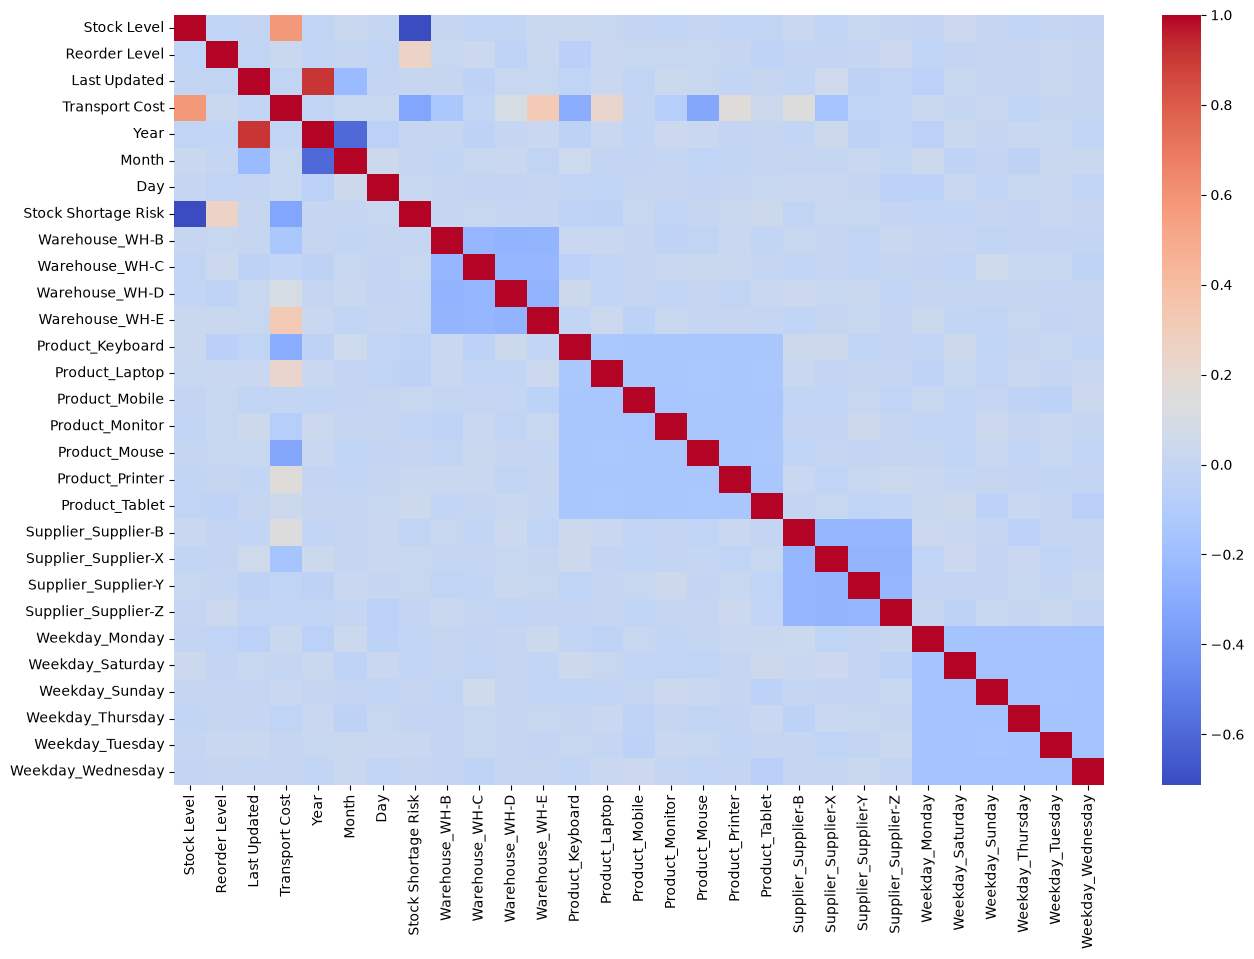

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15,10))

sns.heatmap(
    df_encoded.corr(),
    cmap="coolwarm"
)

plt.show()

In [33]:
df_encoded.head()
df_encoded = df_encoded.drop("Last Updated", axis=1)

# ML

## Regression: Transport Cost

In [34]:
x_reg=df_encoded.drop(
  ["Transport Cost","Stock Shortage Risk"],axis=1

)
y_reg=df_encoded["Transport Cost"]

In [35]:
from sklearn.model_selection import train_test_split

x_train_reg,x_test_reg,y_train_reg,y_test_reg=train_test_split(x_reg,y_reg,random_state=42,test_size=0.2)

In [36]:
x_train_reg.shape
x_test_reg.shape

(400, 26)

## Classification : Stock Shortage Risk

In [38]:
x_cls=df_encoded.drop(
  ['Stock Shortage Risk','Transport Cost']
  ,axis=1
)
y_cls=df_encoded['Stock Shortage Risk']

In [39]:
x_train_cls,x_test_cls,y_train_cls,y_test_cls=train_test_split(x_cls,y_cls,random_state=42,test_size=0.2)

### 1 Linear Regression

In [40]:
from sklearn.linear_model import LinearRegression

In [41]:
lr=LinearRegression()
lr.fit(x_train_reg,y_train_reg)

y_prediction_reg=lr.predict(x_test_reg)
print(y_prediction_reg)

[1971.5961656  2234.51588047 2045.64488036 3957.02834887 1621.54759251
 2170.55731553 1514.5237639  3312.39332522 1472.63878396 2235.32146946
 2048.70018387 2201.63195016 2540.36682457 3500.34081653 2559.94435965
 1674.54820952 1937.52033864 1545.53737488 1716.24784411 2660.01855768
 2181.8559922  1296.22053601 2195.77840587 2485.92320122 2062.27926937
 2048.5542726  1622.20572744 3177.55811815 1920.85128142 2958.99046026
 2201.15793516 2487.94785797 3331.82105414 2654.56365106 2847.71714936
 2818.50505371 2688.60873968 1487.92988956 2081.19939298 2466.20859517
 2761.09428722 2842.39666293 3040.98235233 1621.05242694 2516.86700097
 2055.11734618 2561.57332155 2294.35764789 2542.30990067 1694.48287798
 2883.61445189 2188.52763635 3305.58467607 1982.51226963 1937.21464722
 2361.13151996 2896.06191836 2682.74023281 2998.58357728 2338.35942829
 2300.6674639  2843.00269908 2754.04798651 1864.59988404 2141.41680418
 1405.3944808  2490.16873192 1958.98501513 2776.07491598 2580.90983426
 2602.

In [42]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [43]:
mean_absolute_error(y_test_reg,y_prediction_reg)

186.08780423991476

In [44]:
r2_score(y_test_reg,y_prediction_reg)

0.842241267385107

## PART B : CLASSIFICATION

### 1 Logistic Regression

In [45]:
from sklearn.linear_model import LogisticRegression

In [49]:
log_model=LogisticRegression()
log_model.fit(x_train_cls, y_train_cls)

C:\Users\sarthak\Documents\college\BridzeLabz\Python\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [47]:
y_prediction_classi=log_model.predict(x_test_cls)
print(y_prediction_classi)

[0 1 1 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 1 1 0 1 0 0 0 1 0 0 0 0 0 0 1 0
 1 0 1 0 0 0 1 0 1 1 1 0 1 0 1 0 0 0 0 0 1 0 0 0 1 0 0 1 1 0 0 0 1 0 0 0 1
 0 0 0 1 1 0 1 1 0 0 1 1 0 1 1 0 0 0 0 0 1 0 0 0 0 1 0 1 1 0 0 0 0 0 0 0 0
 0 1 1 0 1 0 0 0 0 0 1 0 1 0 1 0 1 0 0 1 1 1 0 0 1 0 0 0 0 0 1 0 0 0 1 0 0
 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 1 0 1 1 0 1 0 0 0 1 0 0 1 0 0 1 0
 0 0 0 0 0 1 0 0 0 0 1 1 0 0 0 0 1 0 0 1 0 0 1 1 0 1 1 0 0 0 0 0 0 1 0 0 0
 1 0 0 1 0 1 0 0 0 0 1 0 1 0 0 0 1 0 0 1 0 0 0 1 0 0 0 0 0 0 1 0 0 1 0 0 0
 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0
 0 1 0 0 1 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 1 1 1 1 0 1 0 0 0
 1 0 0 0 0 0 1 1 0 1 1 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1
 1 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 1 1 0 1 0 0 0 0 0 0 0 1 0]


In [ ]:
from sklearn.metrics import r2_score , accuracy_score , f1_score , precision_score  , recall_score

In [48]:
print("Accuracy :", accuracy_score(y_test_cls, y_prediction_classi))

print("Precision :", precision_score(y_test_cls, y_prediction_classi))

print("Recall :", recall_score(y_test_cls, y_prediction_classi))

print("F1 :", f1_score(y_test_cls, y_prediction_classi))

print("R2 Score :", r2_score(y_test_cls,y_prediction_classi))

NameError: name 'accuracy_score' is not defined